# Project Title: A Growth-Based Financial Red Flag Screener for North American Apparel Retail

## 1. Problem Definition and Intended User
**Problem:** 
This project builds a simple financial red flag screener for selected sportswear and apparel retail companies. The purpose is to help beginner investors and business students identify potential warning signs by comparing revenue growth with inventory growth, fixed asset growth, and accounts receivable growth over the most recent fiscal years.

This notebook does not aim to prove fraud. Instead, it provides a simple and interpretable screening approach for identifying companies whose business expansion may not be fully supported by sales growth. The output is intended to help users compare firms, spot possible warning signals, and create a watchlist for further analysis.

**Intended User:** This tool is designed for beginner investors and business students. It provides a simple, automated screening framework to compare peer companies within the Apparel Retail industry and identify potential risks before making investment decisions.


## 2. Data Source and Sample
*   **Data Source:** WRDS (Compustat - Fundamentals Annual). 
*   **Date Accessed:** April 18, 2026
*   **Sample:** Eight selected North American listed companies in the sportswear, footwear, and apparel retail market: Nike (NKE), Lululemon (LULU), Under Armour (UAA), VF Corporation (VFC), Skechers (SKX), Columbia Sportswear (COLM), Crocs (CROX), and Foot Locker (FL)
*   **Timeframe:** Fiscal years from 2018 to present.

# 3. Load and Clean Data

In [1]:

import wrds
import pandas as pd

# Connect to WRDS
db = wrds.Connection(wrds_username="your_username") 

# Parameterisation: Define peer companies and start year
tickers = "('NKE', 'LULU', 'UAA','VFC', 'SKX', 'COLM','CROX','FL')"
start_year = 2018

# Parameterised SQL query with strict filters to ensure data quality
# Only industrial format to ensure consistent financial statement structure
# Only standard data format to avoid complications from different reporting styles
# Only domestic population source to focus on US companies
# Only consolidated data to get the full picture of company performance

sql_query = f"""
    SELECT tic, fyear, sale, invt, ppent, rect
    FROM comp.funda
    WHERE tic IN {tickers}
    AND fyear >= {start_year}
    AND indfmt = 'INDL' 
    AND datafmt = 'STD' 
    AND popsrc = 'D' 
    AND consol = 'C'
"""

# Execute query
df = db.raw_sql(sql_query)

# Data Cleaning: Remove duplicates and rows with missing core metrics
df = df.drop_duplicates(subset=['tic', 'fyear'])
df = df.dropna(subset=['sale', 'invt', 'ppent', 'rect'])

# Sort values to ensure accurate growth rate calculations later
df = df.sort_values(by=['tic', 'fyear'])
print("Sample data")
print(df.head())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Sample data
    tic  fyear      sale      invt    ppent     rect
0  COLM   2018  2818.112   521.827  291.596  449.382
1  COLM   2019  3057.965   605.968  741.152  488.233
2  COLM   2020  2513.662    556.53  649.036  452.945
3  COLM   2021  3144.774   645.379  622.016  487.803
4  COLM   2022  3486.172  1028.545  615.623  547.561


## 4. Substantive Python Analysis: Calculate Growth Rates and Apply Warning Rules

In this section, Pandas `pct_change()` is used to calculate the year-on-year growth rates of the four key variables: sales, inventory, fixed assets, and accounts receivable.

**Red Flag Rules:**  
The screening logic compares the growth of inventory, fixed assets, and accounts receivable with sales growth.

- **Flag 1 (Inventory Warning):** Inventory Growth − Sales Growth > 15%  
- **Flag 2 (Fixed Asset Warning):** Fixed Assets Growth − Sales Growth > 15%  
- **Flag 3 (Receivables Warning):** Accounts Receivable Growth − Sales Growth > 20%  

A Python function is then used to check these conditions for each company-year observation and assign a **Warning Count** from 0 to 3.

### 4.1 Calculate Year-over-Year (YoY) Growth Rates

In [2]:
# Use groupby('tic') to ensure calculations remain strictly within each company.
# pct_change() automatically computes the percentage change between the current and prior row.
df['sale_gr'] = df.groupby('tic')['sale'].pct_change()
df['invt_gr'] = df.groupby('tic')['invt'].pct_change()
df['ppent_gr'] = df.groupby('tic')['ppent'].pct_change()
df['rect_gr'] = df.groupby('tic')['rect'].pct_change()

# Review the data to confirm the calculation
# The first year (2018) for each company will show 'NaN' (Not a Number) 
# because there is no 2017 data to compare it against.
print("Growth Rates Calculated:")
display(df[['tic', 'fyear', 'sale_gr', 'invt_gr', 'ppent_gr', 'rect_gr']].head(10))

Growth Rates Calculated:


,tic,fyear,sale_gr,invt_gr,ppent_gr,rect_gr
0,COLM,2018,<NA>,<NA>,<NA>,<NA>
1,COLM,2019,0.085111,0.161243,1.541708,0.086454
2,COLM,2020,-0.177995,-0.081585,-0.124288,-0.072277
3,COLM,2021,0.251073,0.159648,-0.041631,0.076959
4,COLM,2022,0.10856,0.593707,-0.010278,0.122504
5,COLM,2023,0.00651,-0.274424,0.04703,-0.227339
6,COLM,2024,-0.033265,-0.074734,0.058955,-0.013094
7,COLM,2025,0.007968,-0.001534,0.032298,-0.034418
8,CROX,2018,<NA>,<NA>,<NA>,<NA>
9,CROX,2019,0.130847,0.381851,9.338706,0.091168


### 4.2 Apply Red Flag Warning Rules

In [3]:
def calculate_warning_score(row):
    """
    Evaluates growth rate disparities based on specific thresholds.
    Returns a score from 0 to 3 based on how many red flags are triggered.
    """
    # Skip the first year (NaN) since growth rates cannot be calculated
    if pd.isna(row['sale_gr']):
        return 0
    
    warnings = 0
    
    # Flag 1: Inventory Growth − Sales Growth > 15%
    if (row['invt_gr'] - row['sale_gr']) > 0.15:
        warnings += 1
        
    # Flag 2: Fixed Assets Growth − Sales Growth > 15%
    if (row['ppent_gr'] - row['sale_gr']) > 0.15:
        warnings += 1
        
    # Flag 3: Accounts Receivable Growth − Sales Growth > 20%
    if (row['rect_gr'] - row['sale_gr']) > 0.20:
        warnings += 1
        
    return warnings

# Apply the custom function row by row (axis=1)
df['warning_score'] = df.apply(calculate_warning_score, axis=1)

# Drop the first year (NaN values) to only show meaningful analysis years
analysis_df = df.dropna(subset=['sale_gr']).copy()

# Sort by warning score to see the most concerning company-years at the top
analysis_df = analysis_df.sort_values(by='warning_score', ascending=False)

print("=== Top Company-Years with Highest Warning Scores ===")
display(analysis_df[['tic', 'fyear', 'sale_gr', 'invt_gr', 'ppent_gr', 'rect_gr', 'warning_score']].head(20))

=== Top Company-Years with Highest Warning Scores ===


,tic,fyear,sale_gr,invt_gr,ppent_gr,rect_gr,warning_score
32,NKE,2019,-0.043817,0.310388,0.678541,-0.356507,2
27,LULU,2022,0.29631,0.497564,0.293302,0.72603,2
9,CROX,2019,0.130847,0.381851,9.338706,0.091168,2
49,UAA,2022,0.038739,0.466895,0.100846,0.309404,2
1,COLM,2019,0.085111,0.161243,1.541708,0.086454,1
18,FL,2020,-0.057089,-0.235927,-0.058824,0.237624,1
34,NKE,2021,0.048767,0.22848,-0.03742,0.045709,1
33,NKE,2020,0.19076,-0.069635,0.006781,0.623499,1
30,LULU,2025,0.04859,0.179374,0.146089,0.586521,1
46,UAA,2019,0.014239,-0.124805,0.673881,0.088137,1


# 5. Data Visualisation


### 5.1 Identifying the Outliers
Before diving into the operational dynamics of specific firms, we first aggregate the total **Warning Scores** accumulated by each company across the entire analyzed period. This macro-level view helps us immediately identify the most concerning outliers in the industry. As highlighted in red below, the top three firms with the highest cumulative flags will be selected for deeper visual inspection.

In [4]:
%pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


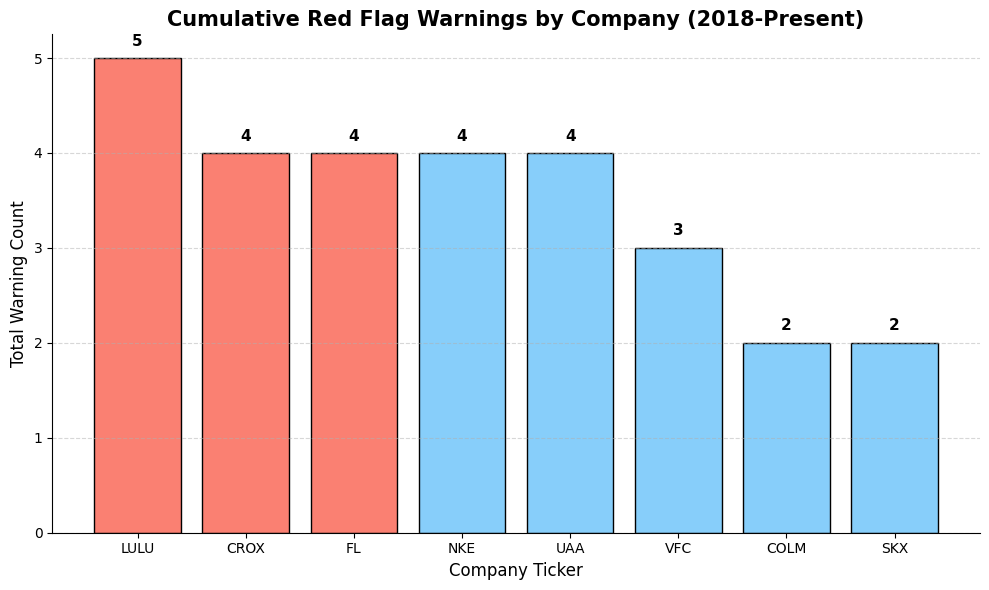

In [5]:

import matplotlib.pyplot as plt

# 1. Calculate total warning score for each company by summing across all years
risk_summary = analysis_df.groupby('tic')['warning_score'].sum().sort_values(ascending=False)

# 2. Set up the figure size for better readability
plt.figure(figsize=(10, 6))

# 3. Plot the bar chart (default color is a soft blue)
bars = plt.bar(risk_summary.index, risk_summary.values, color='#87CEFA', edgecolor='black')

# 4. Visually highlight the top 3 companies with the highest cumulative warning scores in a soft warning red color
for i in range(min(3, len(bars))): 
    bars[i].set_color('#FA8072') #  (Salmon)
    bars[i].set_edgecolor('black')

# 5. Add title and axis labels with enhanced font styling for better aesthetics
plt.title('Cumulative Red Flag Warnings by Company (2018-Present)', fontsize=15, fontweight='bold')
plt.xlabel('Company Ticker', fontsize=12)
plt.ylabel('Total Warning Count', fontsize=12)

# 6. Add data labels on top of each bar to show the exact warning count, but only if it's greater than 0 to keep the chart clean
for bar in bars:
    yval = bar.get_height()
    # Only show the data label if the warning count is greater than 0 to avoid cluttering the chart with zeros
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# 7. Aesthetic adjustments: Remove top and right spines for a cleaner look, and add grid lines for better readability
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### 5.2 Deep Dive: Visualizing Operational Divergence

This section takes a closer look at the three companies with the highest warning scores.

The charts show how **inventory**, **fixed assets**, and **receivables** growth compare with **sales growth**. When these indicators rise much faster than sales, it may be a warning sign. This helps identify which metric triggered the red flag and when the divergence was most obvious.

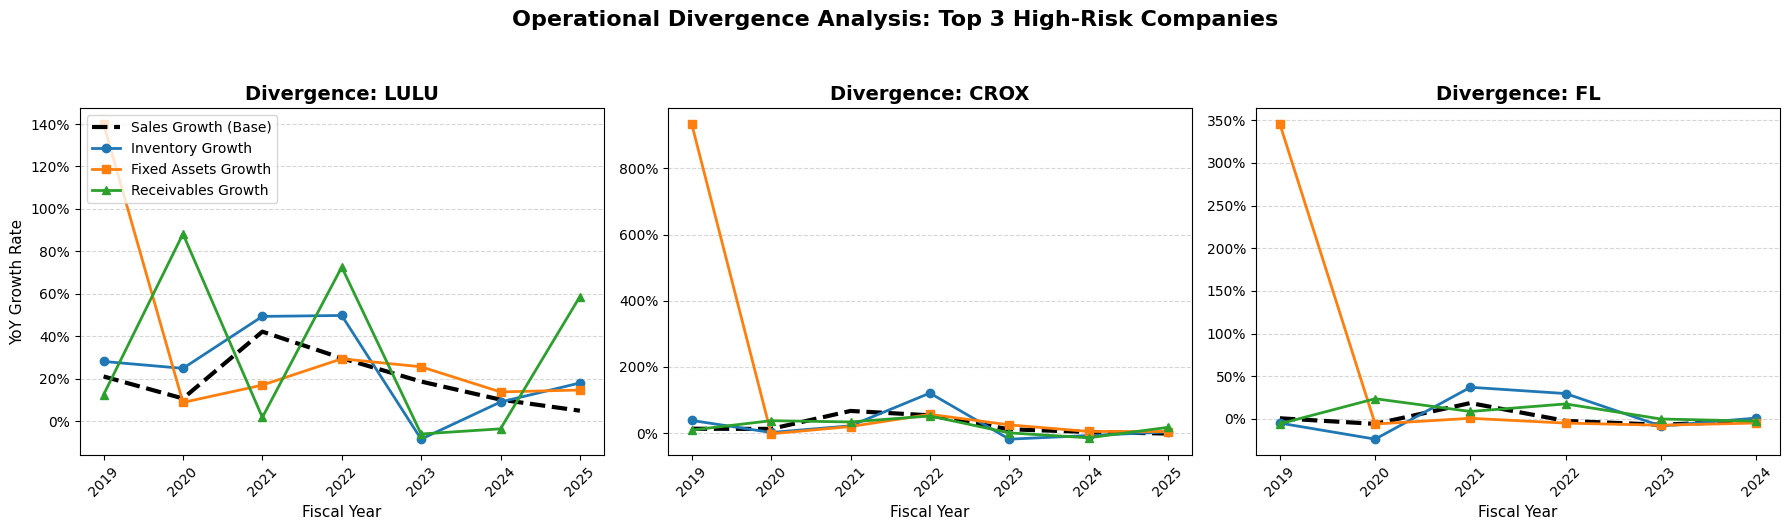

In [6]:

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Identify the top 3 companies with the highest cumulative warning scores for deeper analysis
top_3_to_analyze = risk_summary.index[:3]

# 2. Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, ticker in enumerate(top_3_to_analyze):
    ax = axes[i]
    df_ticker = analysis_df[analysis_df['tic'] == ticker].copy()
    
    # Sort by year to ensure correct x-axis order
    df_ticker = df_ticker.sort_values(by='fyear')
    
    # Create numeric x-axis positions and year labels to avoid sorting issues
    x_positions = range(len(df_ticker))
    year_labels = df_ticker['fyear'].astype(int).astype(str).values
    
    # Plot the lines using numeric positions
    ax.plot(x_positions, df_ticker['sale_gr'].values, label='Sales Growth (Base)', color='black', linewidth=3, linestyle='--')
    ax.plot(x_positions, df_ticker['invt_gr'].values, label='Inventory Growth', marker='o', linewidth=2)
    ax.plot(x_positions, df_ticker['ppent_gr'].values, label='Fixed Assets Growth', marker='s', linewidth=2)
    ax.plot(x_positions, df_ticker['rect_gr'].values, label='Receivables Growth', marker='^', linewidth=2)
    
    # Set x-axis labels and positions
    ax.set_xticks(x_positions)
    ax.set_xticklabels(year_labels, rotation=45)
    
    # title and labels
    ax.set_title(f'Divergence: {ticker}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Fiscal Year', fontsize=11)
    
    # add Y-axis formatting and grid lines for better readability
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Only add Y-axis label and legend to the first subplot for a cleaner look
    if i == 0:
        ax.set_ylabel('YoY Growth Rate', fontsize=11)
        ax.legend(loc='upper left', fontsize=10, frameon=True)

# 4. Add a main title for the entire figure and adjust layout for better aesthetics
plt.suptitle('Operational Divergence Analysis: Top 3 High-Risk Companies', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Close database connection after all analysis is complete
db.close()

## 6. Interpretation and Findings

### Key Results

Three companies stand out as outliers: **Lululemon (LULU), Crocs (CROX), and Foot Locker (FL)** showed the highest cumulative warning scores across 2018–present. In contrast, **Columbia Sportswear (COLM) and Skechers (SKX)** maintained relatively balanced growth dynamics with minimal red flags.

The primary drivers of these warnings were:
- Inventory levels growing significantly faster than sales
- Fixed asset investments expanding beyond revenue growth
- Accounts receivable accumulating disproportionately to sales

---

### What the Data Visualizations Reveal

**Figure 5.1 (Cumulative Risk Overview):**
This bar chart provides an immediate snapshot: which companies accumulated the most warning signals over the study period. Companies with higher bars suggest a pattern rather than an isolated event—repeated years with growth misalignment warrant attention. The sharp visual separation between LULU/CROX/FL (red bars) and peers makes risk prioritization straightforward for analysts.

**Figure 5.2 (Year-by-Year Divergence Patterns):**
The three trend charts zoom into the specific years and metrics driving concern. For each high-risk company, you can see when inventory, fixed assets, or receivables spiked relative to sales. Some divergences appear temporary (single-year anomalies), while others persist across multiple years, suggesting systemic operational or strategic shifts rather than one-off occurrences. The comparison between the three companies also reveals different risk profiles—for instance, one company might struggle with inventory buildup while another faces receivables management issues.

---

### Conclusion

**Practical Takeaway:**
This screener successfully identifies companies whose operational metrics diverge from growth trajectories. Rather than flagging definitive fraud or mismanagement, it surfaces companies worthy of deeper investigation. For beginner investors and analysts, the tool cuts through noise by focusing on a simple, interpretable metric: when business expansion (measured by assets and inventory) outpaces revenue, it raises questions worth asking.

**Next Steps for Investors:**
1. Use this screening tool to build an initial watchlist
2. For flagged companies, cross-reference SEC filings to understand *why* these divergences occurred (e.g., is it intentional capacity building for anticipated growth, or operational stress?)
3. Combine with qualitative analysis—management commentary, industry trends, competitive positioning—to inform investment decisions

**For Practitioners:**
This framework is extensible. Users can adjust thresholds (currently 15% and 20%) based on industry norms, refine the peer sample, or incorporate additional metrics (e.g., cash flow, operating efficiency) for more nuanced screening.

---

### Limitations

1. **Statistical Anomalies ≠ Red Flags:** The tool identifies unusual patterns in financial metrics, not definitive proof of problems. Rapid growth, acquisitions, or supply chain disruptions can legitimately cause these divergences.

2. **Survivorship and Sample Bias:** This analysis covers eight publicly listed companies in the U.S. apparel sector. Results may not generalize to smaller firms, private companies, or other industries.

3. **Time-Specific Context Matters:** The 2018–present window captures COVID-era supply chain chaos, e-commerce acceleration, and post-pandemic restructuring—all of which inflated asset and inventory levels industry-wide. Historical thresholds may need adjustment for different periods.

4. **Requires Qualitative Follow-Up:** Red flags are starting points, not conclusions. SEC filings, earnings calls, and industry reports must accompany this quantitative screening for informed decision-making.

5. **Data Classification and Timing:** Significant growth spikes in specific years (e.g., high fixed asset growth in 2019) may reflect legitimate operational events such as acquisitions, store expansion, capital restructuring, or accounting reclassifications rather than financial anomalies. Users should validate findings against raw financial data and management commentary to understand the drivers.